# UC1 — Results (reframed)

Same saved JSONs as `04_Results.ipynb`, **no retraining**, loaded via `reframe_results.py`.
Reproduces your original pooled-AUC results exactly **and** reports the client-local view so
UC1 can be compared like-for-like with UC2.

**Two metric families (both shown):**
- **Pooled** `test_auc` — your original headline. All clients' predictions concatenated into
  one ROC. Standard in the FedGen literature. Identical to your `Mean AUC` (verified < 1e-4).
- **Client-local** — each client scored on its **own** test set, then averaged. This is the
  metric that is *equivalent to UC2's `newpart`* (UC2 also evaluates per-client and averages).
  - `perclient_wmean` — **size-weighted** average (matches UC2's sample-weighted aggregation) → **use this for the UC1↔UC2 comparison**
  - `perclient_mean` — equal-weight (macro) average — every hospital counts the same (equity view)
  - `perclient_worst_mean` — the worst single hospital

⚠️ **Pooled ≠ client-local for AUC.** AUC is a ranking metric, so concatenating clients is not
the same as averaging their AUCs (unlike MSE, where they coincide — which is why UC2's number
is unambiguous). The gap is largest at low α. State explicitly in the thesis which one a given
figure uses.

Caveat unchanged: one Dirichlet partition per α (seeds reseed init only) → ±std is init noise.

In [1]:
import sys, os, importlib
sys.path.append('..')                       # so we can import reframe_results.py
import reframe_results as R
importlib.reload(R)                          # in case we edited it since last import

import pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
print('reframe_results from:', R.BASE)


reframe_results from: /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 1 (Health)


## 1. Load all results & export the CSV (both data cases)

In [2]:
df = R.build_dataframe(data_cases=('filtered', 'unfiltered'))
csv_path = R.write_csv('reframed_results.csv', df=df)     # pops the CSV next to this notebook
print('CSV ->', csv_path, '|', len(df), 'rows')
df.head(12)


CSV -> reframed_results.csv | 252 rows


,data_case,variant,sharing,alpha,n_seeds,test_auc_mean,test_auc_std,client_sigma,rounds,final_mb,final_mb_saved,perclient_wmean,perclient_mean,perclient_std,perclient_worst_mean,valsel_pooled_mean,artifact
0,filtered,fedavg_full,full,0.1,3,0.5771,0.0055,0.0602,20.0,165.919,165.919,0.6057,0.5641,0.0063,0.4902,0.5771,False
1,filtered,fedavg_full,full,0.5,3,0.6438,0.0010,0.0382,6.7,55.306,55.306,0.6576,0.6586,0.0016,0.6121,0.6438,False
2,filtered,fedavg_full,full,1.0,3,0.6150,0.0027,0.0369,7.7,63.602,63.602,0.6436,0.6237,0.0025,0.5817,0.6150,False
3,filtered,fedavg_full,full,5.0,3,0.6395,0.0011,0.0332,12.0,99.552,99.552,0.6574,0.6596,0.0014,0.5968,0.6395,False
4,filtered,fedavg_full,full,10.0,3,0.6481,0.0016,0.0254,10.3,85.725,85.725,0.6549,0.6520,0.0010,0.6166,0.6481,False
5,filtered,fedavg_partial,partial,0.1,3,0.6472,0.0238,0.0384,12.3,0.121,0.121,0.5969,0.5753,0.0058,0.5192,0.7006,False
6,filtered,fedavg_partial,partial,0.5,3,0.6059,0.0089,0.0226,9.3,0.092,0.092,0.5814,0.5747,0.0009,0.5507,0.6231,False
7,filtered,fedavg_partial,partial,1.0,3,0.6139,0.0034,0.0317,11.0,0.108,0.108,0.5885,0.5682,0.0051,0.5355,0.6478,False
8,filtered,fedavg_partial,partial,5.0,3,0.6044,0.0131,0.0204,10.7,0.105,0.105,0.5832,0.5829,0.0060,0.5493,0.6413,False
9,filtered,fedavg_partial,partial,10.0,3,0.6116,0.0153,0.0192,8.3,0.082,0.082,0.5851,0.5836,0.0038,0.5530,0.6228,False


## 2. Summary tables — pooled vs client-local

Three tables per data case: (1) **pooled `test_auc`** (your original metric), (2)
**client-local size-weighted** `perclient_wmean` — *the UC2-comparable metric*, (3)
client-local equal-weight `perclient_mean` (equity view). Compare table 2 here directly
against UC2's `newpart` MSE table.

In [3]:
_tables = [('valsel_pooled_mean', 'POOLED AUC (checkpoint-consistent, val-selected; == test_auc for full)'),
           ('perclient_wmean', 'CLIENT-LOCAL size-weighted  (== UC2 newpart aggregation)'),
           ('perclient_mean',  'CLIENT-LOCAL equal-weight  (equity view)')]
for dc in ['filtered', 'unfiltered']:
    sub = df[df.data_case == dc]
    if sub.empty:
        continue
    for col, title in _tables:
        print(f'\n========  {dc.upper()}  —  {title}  ========')
        display(sub.pivot_table(index=['sharing', 'variant'], columns='alpha',
                                values=col).round(3))


========  FILTERED  —  POOLED AUC (checkpoint-consistent, val-selected; == test_auc for full)  ========


alpha                                    0.1    0.5    1.0    5.0    10.0
sharing variant                                                          
full    fedavg_full                     0.577  0.644  0.615  0.640  0.648
        fedgen_full                     0.582  0.644  0.619  0.639  0.650
        fedgen_full_medoid              0.583  0.644  0.618  0.640  0.649
        fedgen_gmm_full                 0.582  0.646  0.618  0.640  0.649
        fedgen_paper_full               0.587  0.644  0.620  0.638  0.650
        fedgen_paper_full_medoid        0.583  0.646  0.616  0.639  0.650
        fedgen_paper_full_no_proto      0.585  0.644  0.618  0.639  0.651
        fedgen_zhu_code_full            0.586  0.645  0.618  0.640  0.648
        fedgen_zhu_code_full_medoid     0.583  0.645  0.618  0.640  0.649
        fedgen_zhu_full                 0.585  0.644  0.618  0.640  0.649
        fedgen_zhu_full_medoid          0.584  0.646  0.616  0.641  0.649
        fedgen_zhu_full_no_proto        0.577  0.646  0.614  0.640  0.649
        fedgen_zhu_pyhat_full           0.584  0.644  0.618  0.640  0.649
        fedgen_zhu_pyhat_full_medoid    0.586  0.643  0.616  0.639  0.650
partial fedavg_partial                  0.701  0.623  0.648  0.641  0.623
        fedgen_gmm                      0.720  0.640  0.655  0.663  0.623
        fedgen_paper_partial            0.689  0.635  0.638  0.638  0.622
        fedgen_paper_partial_medoid     0.688  0.634  0.634  0.643  0.620
        fedgen_paper_partial_no_proto   0.694  0.639  0.639  0.639  0.616
        fedgen_partial                  0.707  0.649  0.638  0.640  0.625
        fedgen_partial_medoid           0.714  0.648  0.654  0.645  0.625
        fedgen_zhu                      0.693  0.631  0.657  0.651  0.626
        fedgen_zhu_code_partial         0.702  0.636  0.626  0.646  0.632
        fedgen_zhu_code_partial_medoid  0.698  0.636  0.636  0.651  0.628
        fedgen_zhu_medoid               0.706  0.632  0.670  0.653  0.624
        fedgen_zhu_no_proto             0.703  0.630  0.640  0.652  0.623
        fedgen_zhu_pyhat                0.714  0.626  0.646  0.649  0.625
        fedgen_zhu_pyhat_medoid         0.709  0.636  0.651  0.646  0.623


========  FILTERED  —  CLIENT-LOCAL size-weighted  (== UC2 newpart aggregation)  ========


alpha                                    0.1    0.5    1.0    5.0    10.0
sharing variant                                                          
full    fedavg_full                     0.606  0.658  0.644  0.657  0.655
        fedgen_full                     0.634  0.658  0.648  0.656  0.657
        fedgen_full_medoid              0.626  0.658  0.645  0.658  0.656
        fedgen_gmm_full                 0.634  0.659  0.646  0.658  0.656
        fedgen_paper_full               0.610  0.658  0.648  0.656  0.657
        fedgen_paper_full_medoid        0.631  0.659  0.645  0.657  0.658
        fedgen_paper_full_no_proto      0.619  0.658  0.646  0.657  0.658
        fedgen_zhu_code_full            0.622  0.659  0.648  0.659  0.655
        fedgen_zhu_code_full_medoid     0.616  0.659  0.647  0.658  0.655
        fedgen_zhu_full                 0.619  0.657  0.647  0.657  0.656
        fedgen_zhu_full_medoid          0.629  0.659  0.644  0.659  0.656
        fedgen_zhu_full_no_proto        0.611  0.659  0.643  0.658  0.656
        fedgen_zhu_pyhat_full           0.618  0.657  0.646  0.658  0.656
        fedgen_zhu_pyhat_full_medoid    0.625  0.657  0.644  0.656  0.657
partial fedavg_partial                  0.597  0.581  0.588  0.583  0.585
        fedgen_gmm                      0.575  0.568  0.549  0.542  0.583
        fedgen_paper_partial            0.592  0.584  0.586  0.586  0.580
        fedgen_paper_partial_medoid     0.596  0.579  0.581  0.578  0.583
        fedgen_paper_partial_no_proto   0.595  0.582  0.575  0.589  0.583
        fedgen_partial                  0.590  0.580  0.586  0.582  0.578
        fedgen_partial_medoid           0.590  0.582  0.569  0.570  0.582
        fedgen_zhu                      0.597  0.589  0.578  0.583  0.583
        fedgen_zhu_code_partial         0.594  0.579  0.587  0.583  0.578
        fedgen_zhu_code_partial_medoid  0.597  0.584  0.579  0.585  0.573
        fedgen_zhu_medoid               0.595  0.587  0.568  0.589  0.582
        fedgen_zhu_no_proto             0.594  0.585  0.583  0.584  0.586
        fedgen_zhu_pyhat                0.598  0.581  0.587  0.585  0.581
        fedgen_zhu_pyhat_medoid         0.594  0.585  0.596  0.586  0.582


========  FILTERED  —  CLIENT-LOCAL equal-weight  (equity view)  ========


...

alpha                                    0.5    1.0    5.0    10.0
sharing variant                                                   
full    fedavg_full                     0.583  0.608  0.640  0.648
        fedgen_full                     0.580  0.607  0.639  0.650
        fedgen_full_medoid              0.580  0.607  0.640  0.649
        fedgen_gmm_full                 0.586  0.607  0.640  0.649
        fedgen_paper_full               0.584  0.608  0.638  0.650
        fedgen_paper_full_medoid        0.584  0.610  0.639  0.650
        fedgen_paper_full_no_proto      0.586  0.609  0.639  0.651
        fedgen_zhu_code_full            0.586  0.608  0.640  0.648
        fedgen_zhu_code_full_medoid     0.586  0.608  0.640  0.649
        fedgen_zhu_full                 0.585  0.606  0.640  0.649
        fedgen_zhu_full_medoid          0.582  0.606  0.641  0.649
        fedgen_zhu_full_no_proto        0.582  0.607  0.640  0.649
        fedgen_zhu_pyhat_full           0.584  0.608  0.640  0.649
        fedgen_zhu_pyhat_full_medoid    0.586  0.609  0.639  0.650
partial fedavg_partial                  0.808  0.750  0.641  0.623
        fedgen_gmm                      0.801  0.760  0.663  0.623
        fedgen_paper_partial            0.805  0.750  0.638  0.622
        fedgen_paper_partial_medoid     0.803  0.768  0.643  0.620
        fedgen_paper_partial_no_proto   0.805  0.741  0.639  0.616
        fedgen_partial                  0.807  0.758  0.640  0.625
        fedgen_partial_medoid           0.806  0.756  0.645  0.625
        fedgen_zhu                      0.810  0.738  0.651  0.626
        fedgen_zhu_code_partial         0.806  0.765  0.646  0.632
        fedgen_zhu_code_partial_medoid  0.804  0.758  0.651  0.628
        fedgen_zhu_medoid               0.805  0.711  0.653  0.624
        fedgen_zhu_no_proto             0.796  0.700  0.652  0.623
        fedgen_zhu_pyhat                0.804  0.757  0.649  0.625
        fedgen_zhu_pyhat_medoid         0.798  0.724  0.646  0.623


========  UNFILTERED  —  CLIENT-LOCAL size-weighted  (== UC2 newpart aggregation)  ========


alpha                                    0.5    1.0    5.0    10.0
sharing variant                                                   
full    fedavg_full                     0.632  0.722  0.657  0.655
        fedgen_full                     0.627  0.731  0.656  0.657
        fedgen_full_medoid              0.627  0.720  0.658  0.656
        fedgen_gmm_full                 0.634  0.724  0.658  0.656
        fedgen_paper_full               0.634  0.718  0.656  0.657
        fedgen_paper_full_medoid        0.643  0.714  0.657  0.658
        fedgen_paper_full_no_proto      0.632  0.731  0.657  0.658
        fedgen_zhu_code_full            0.638  0.703  0.659  0.655
        fedgen_zhu_code_full_medoid     0.635  0.731  0.658  0.655
        fedgen_zhu_full                 0.631  0.724  0.657  0.656
        fedgen_zhu_full_medoid          0.625  0.704  0.659  0.656
        fedgen_zhu_full_no_proto        0.625  0.700  0.658  0.656
        fedgen_zhu_pyhat_full           0.642  0.730  0.658  0.656
        fedgen_zhu_pyhat_full_medoid    0.635  0.733  0.656  0.657
partial fedavg_partial                  0.531  0.561  0.583  0.585
        fedgen_gmm                      0.527  0.637  0.542  0.583
        fedgen_paper_partial            0.516  0.588  0.586  0.580
        fedgen_paper_partial_medoid     0.499  0.543  0.578  0.583
        fedgen_paper_partial_no_proto   0.516  0.564  0.589  0.583
        fedgen_partial                  0.527  0.514  0.582  0.578
        fedgen_partial_medoid           0.546  0.445  0.570  0.582
        fedgen_zhu                      0.529  0.485  0.583  0.583
        fedgen_zhu_code_partial         0.545  0.503  0.583  0.578
        fedgen_zhu_code_partial_medoid  0.530  0.582  0.585  0.573
        fedgen_zhu_medoid               0.541  0.462  0.589  0.582
        fedgen_zhu_no_proto             0.572  0.548  0.584  0.586
        fedgen_zhu_pyhat                0.543  0.590  0.585  0.581
        fedgen_zhu_pyhat_medoid         0.527  0.556  0.586  0.582


========  UNFILTERED  —  CLIENT-LOCAL equal-weight  (equity view)  ========


alpha                                    0.5    1.0    5.0    10.0
sharing variant                                                   
full    fedavg_full                     0.606  0.662  0.660  0.652
        fedgen_full                     0.600  0.668  0.658  0.654
        fedgen_full_medoid              0.600  0.662  0.660  0.653
        fedgen_gmm_full                 0.607  0.663  0.660  0.653
        fedgen_paper_full               0.607  0.660  0.657  0.654
        fedgen_paper_full_medoid        0.613  0.659  0.659  0.655
        fedgen_paper_full_no_proto      0.604  0.668  0.658  0.655
        fedgen_zhu_code_full            0.610  0.651  0.661  0.652
        fedgen_zhu_code_full_medoid     0.610  0.669  0.660  0.652
        fedgen_zhu_full                 0.604  0.664  0.659  0.653
        fedgen_zhu_full_medoid          0.599  0.651  0.660  0.653
        fedgen_zhu_full_no_proto        0.599  0.648  0.659  0.653
        fedgen_zhu_pyhat_full           0.611  0.668  0.659  0.653
        fedgen_zhu_pyhat_full_medoid    0.606  0.670  0.658  0.654
partial fedavg_partial                  0.555  0.564  0.583  0.584
        fedgen_gmm                      0.550  0.610  0.546  0.583
        fedgen_paper_partial            0.544  0.581  0.586  0.579
        fedgen_paper_partial_medoid     0.530  0.555  0.580  0.582
        fedgen_paper_partial_no_proto   0.542  0.567  0.589  0.583
        fedgen_partial                  0.556  0.537  0.583  0.578
        fedgen_partial_medoid           0.564  0.494  0.573  0.580
        fedgen_zhu                      0.556  0.518  0.583  0.582
        fedgen_zhu_code_partial         0.565  0.529  0.583  0.578
        fedgen_zhu_code_partial_medoid  0.555  0.578  0.583  0.574
        fedgen_zhu_medoid               0.561  0.503  0.589  0.582
        fedgen_zhu_no_proto             0.582  0.556  0.585  0.585
        fedgen_zhu_pyhat                0.562  0.584  0.586  0.581
        fedgen_zhu_pyhat_medoid         0.552  0.562  0.588  0.582

## 3. Accuracy vs heterogeneity — partial | full

Row 1 = **pooled AUC, checkpoint-consistent** (`valsel_pooled`: identical to the saved
`test_auc` for full variants; for partial variants it is the test AUC at the best-validation
round, fixing the best-predictor/final-encoder pairing — see §7 and Limitation 3).
Row 2 = **client-local size-weighted** AUC (the UC2-comparable metric). On pooled, FedGen
partial sits above `fedavg_partial` and the gap grows at low α (theory-consistent); the
client-local view is flatter — the same pooled-vs-local story quantified in §4.

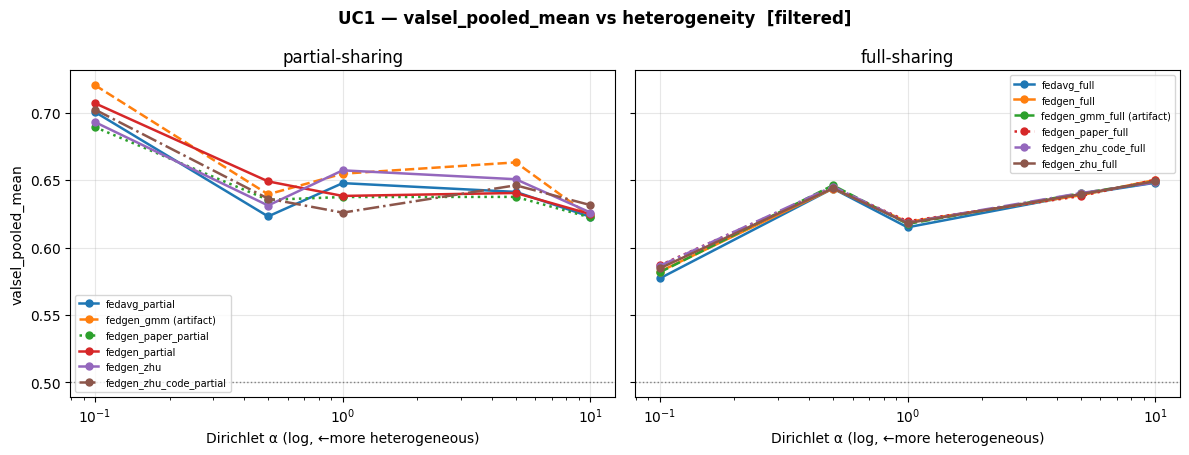

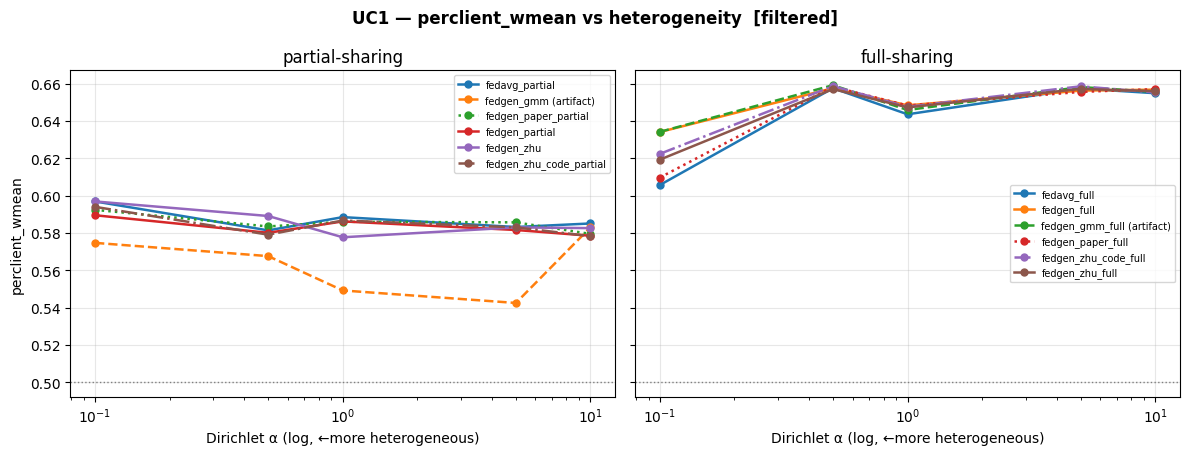

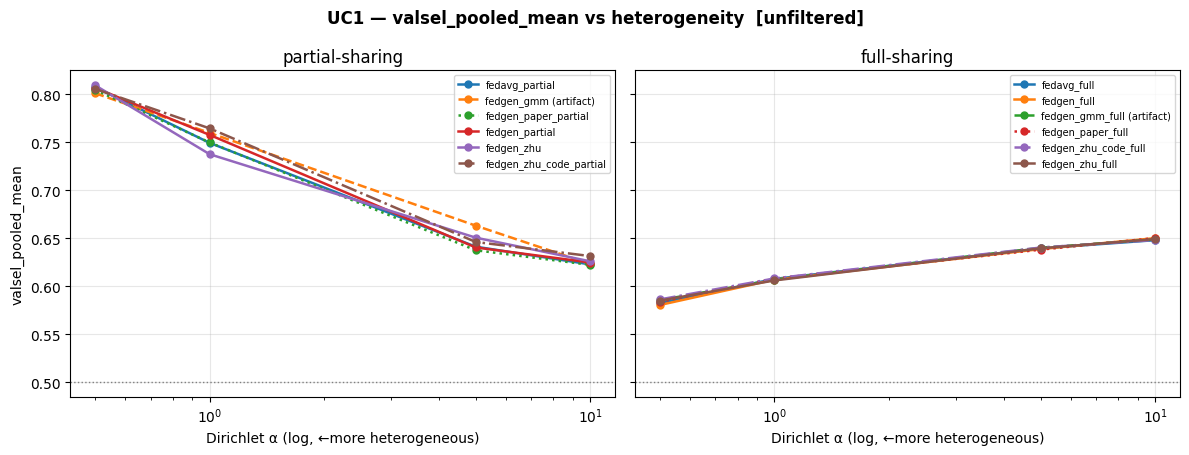

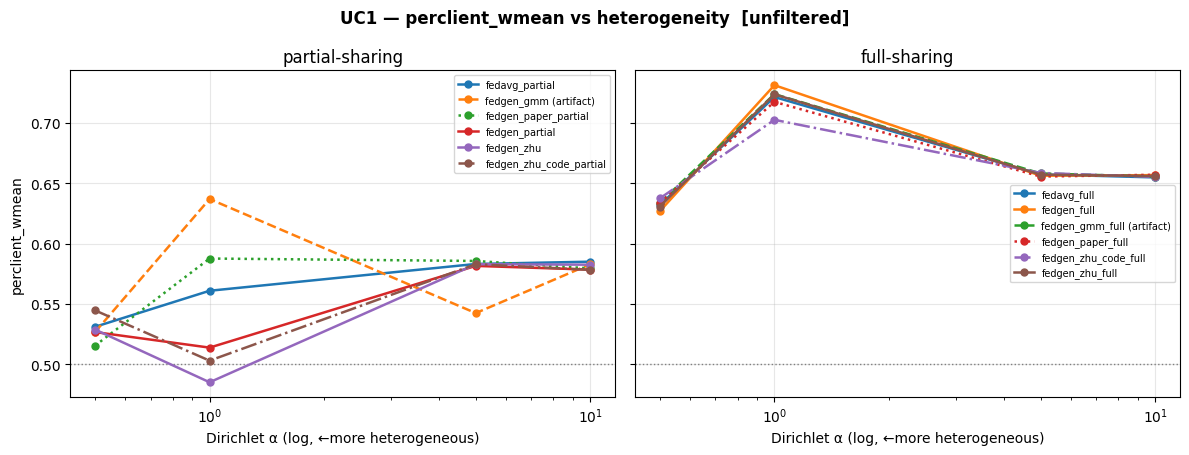

In [4]:
for dc in ['filtered', 'unfiltered']:
    if df[df.data_case == dc].empty:
        continue
    # pooled, checkpoint-consistent (valsel == saved test_auc for full variants;
    # for partial it is the value at the best-val round — see Limitation 3)
    R.plot_auc_vs_alpha(df, dc, metric='valsel_pooled_mean'); plt.show()
    R.plot_auc_vs_alpha(df, dc, metric='perclient_wmean'); plt.show()   # client-local (UC2-comparable)

## 4. Robustness: where pooled and per-client diverge

`pooled − per-client AUC`, averaged over variants, by α. The gap is largest at low α: under
high heterogeneity the pooled metric is partly rewarded for separating *clients* (different
base rates), not only patients within a client. This doesn't make your pooled numbers wrong —
it just means the per-client view (§2–3 second row) is the right sanity check at low α.

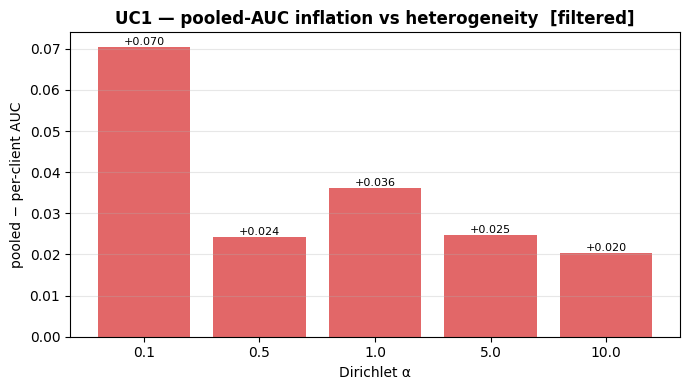

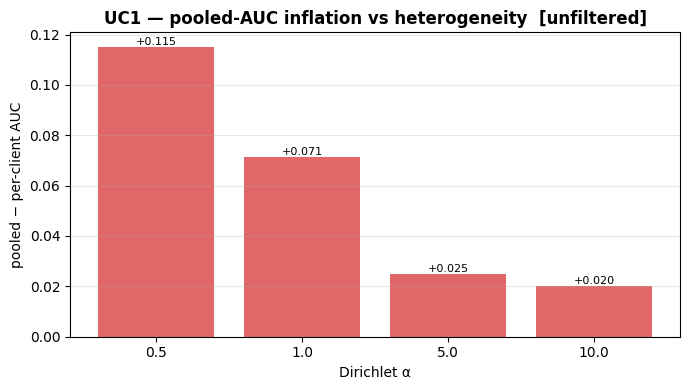

In [5]:
for dc in ['filtered', 'unfiltered']:
    if not df[df.data_case == dc].empty:
        R.plot_pooled_vs_perclient(df, dc); plt.show()


## 5. Accuracy–communication frontier

The thesis axis: AUC vs cumulative MB (log). First plot uses the **checkpoint-consistent
pooled AUC** (`valsel_pooled`), second uses per-client (robustness). Partial variants
(≈0.1–1.9 MB) vs full (≈55–166 MB) — the ~100–600× communication gap is the headline.
GMM circled = flagged artifact (high pooled AUC, per-client ≈ 0.55).

**MB axis note:** `final_mb` is the *corrected* accounting — the client→server uploads of
per-class latent prototypes (anchor-using variants) and GMM distributions, omitted by the
run loops, are added analytically in `reframe_results.py` (validated against the saved
`cumul_mb` first; original values kept in `final_mb_saved`). Effect: FedAvg and no-anchor
variants unchanged; FedGen-partial ≈ +9%; full variants ≈ +0.1%; GMM ≈ +50%.

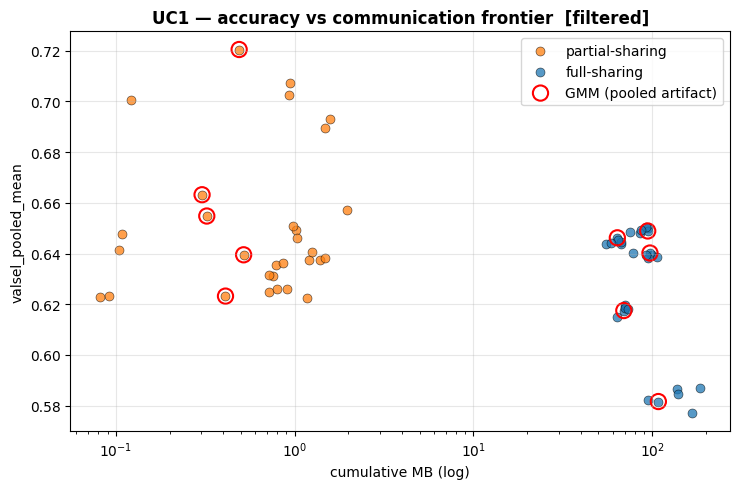

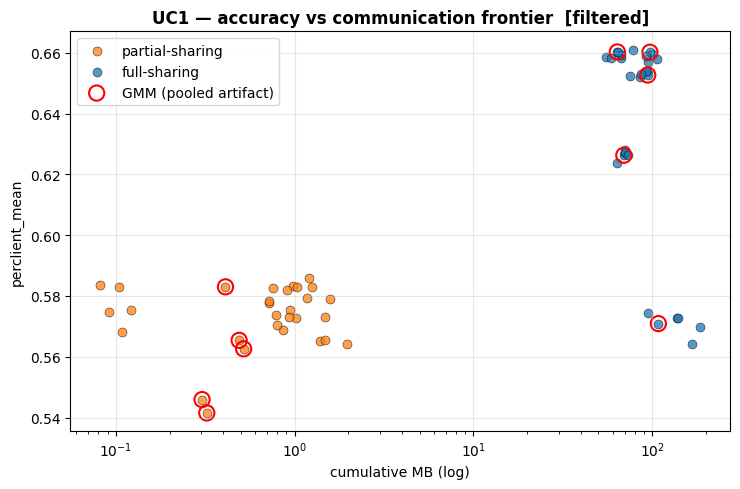

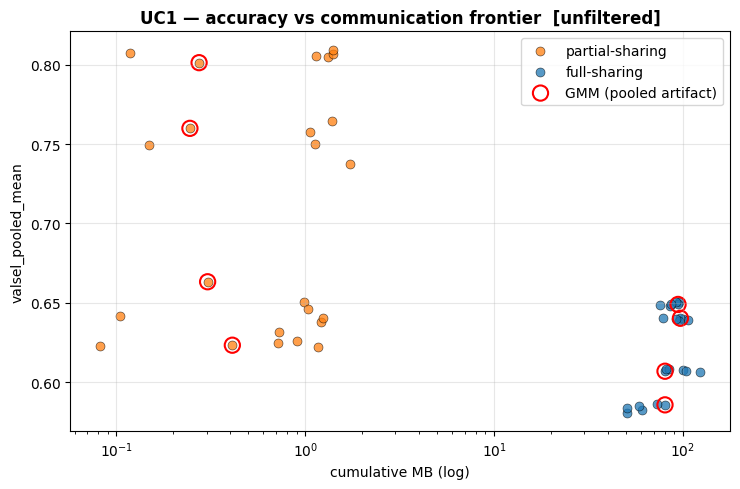

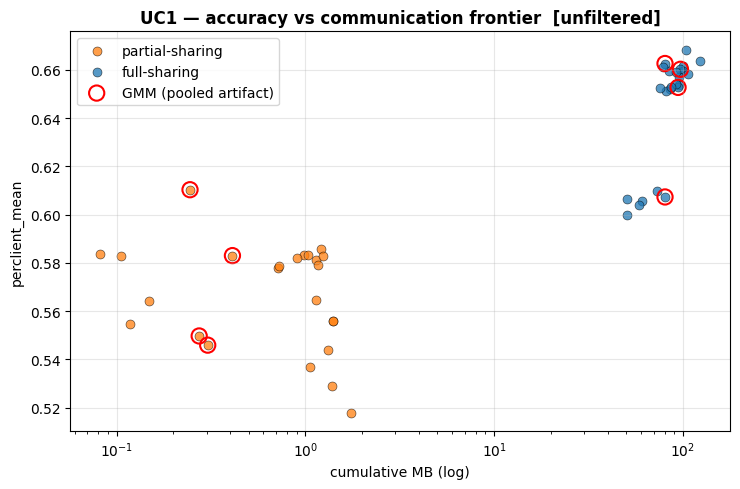

In [6]:
for dc in ['filtered', 'unfiltered']:
    if df[df.data_case == dc].empty:
        continue
    # x-axis: final_mb is the CORRECTED communication (prototype/GMM uploads
    # included, recomputed in reframe_results.py; original kept in final_mb_saved)
    R.plot_pareto(df, dc, metric='valsel_pooled_mean'); plt.show()   # pooled, checkpoint-consistent
    R.plot_pareto(df, dc, metric='perclient_mean'); plt.show()       # robustness

## 6. Worst-served client (equity)

Min per-client AUC. Under high heterogeneity the *full* models can drive the
worst client below 0.5 (worse than random); cheap partial models stay ~0.52.

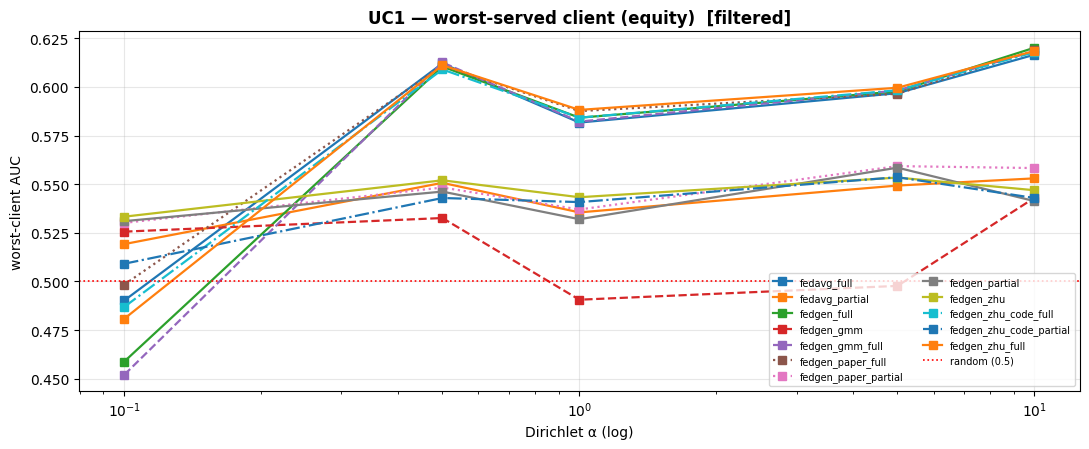

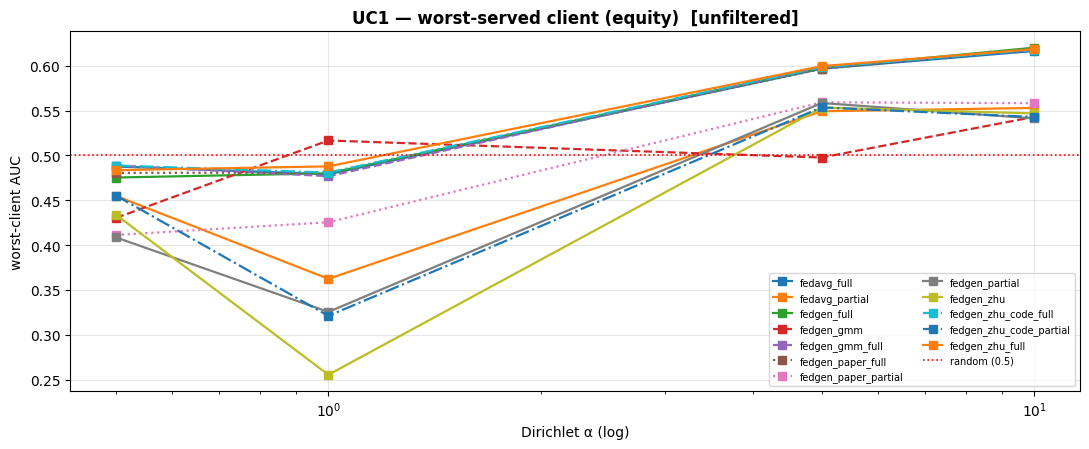

In [7]:
for dc in ['filtered', 'unfiltered']:
    if not df[df.data_case == dc].empty:
        R.plot_worst_client(df, dc); plt.show()


## 7. Checkpoint-inconsistency diagnostic

`saved_pooled − valsel_pooled`. Full variants: exactly 0 (whole model checkpointed).
Partial variants: every run differs (best predictor was paired with the final-round
encoder) — which is why partial headline numbers use `valsel_pooled`.

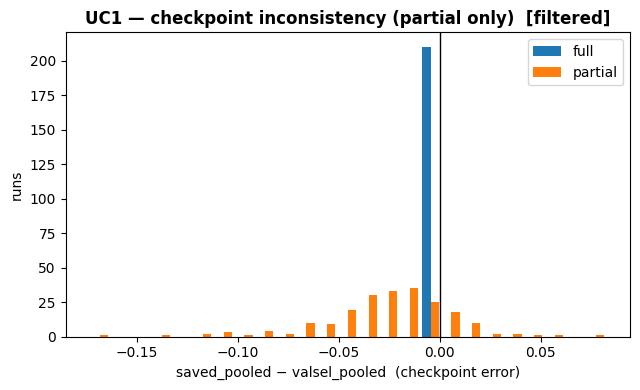

In [8]:
R.plot_checkpoint_correction('filtered'); plt.show()


## 8. Statistical significance — Wilcoxon signed-rank (your original test, restored)

Reproduces `04_Results.ipynb` cell 21 exactly: each FedGen variant vs its **matched**
baseline (`fedavg_partial` / `fedavg_full`), paired by α×seed (n=15), exact two-sided
signed-rank. Run on three metrics so significance can be compared side by side:
`saved_pooled` (your original headline), `valsel_pooled` (checkpoint-fixed), and
`perclient_mean` (honest, decision-relevant).

**How to read it:**
- **Full family** — FedGen is significantly, but *tinily* (Δ≈+0.002–0.003), better than
  FedAvg under **all three** metrics. The significance comes from near-zero seed variance
  (one fixed partition per α), so read it as "consistent but partition-fragile," not a
  large effect.
- **Partial family** — the FedGen advantage is **metric-dependent**: `fedgen_zhu*` are
  significant on pooled AUC (your finding holds) but not on per-client; `fedgen_gmm` is
  significantly *worse* on per-client (the client-separation artifact).

`*** p<0.001   ** p<0.01   * p<0.05   ns`. (Exact signed-rank, no scipy dependency —
`R.wilcoxon_signed_rank` matches `scipy.stats.wilcoxon` for these n.)

In [9]:
for metric in ['saved_pooled', 'valsel_pooled', 'perclient_mean']:
    sig = R.significance_table(metric=metric, data_cases=('filtered',))
    print(f'\n========  Wilcoxon vs matched FedAvg — metric = {metric}  [filtered]  ========')
    display(sig[['family', 'variant', 'n_pairs', 'delta', 'W', 'p', 'sig', 'better']]
            .sort_values(['family', 'p']).reset_index(drop=True))

# compact summary: significant (p<0.05) FedGen wins / losses per family & metric
print('\nSummary (filtered): significant FedGen wins / losses (p<0.05)')
for metric in ['saved_pooled', 'valsel_pooled', 'perclient_mean']:
    sig = R.significance_table(metric=metric, data_cases=('filtered',))
    for fam in ['partial', 'full']:
        f = sig[sig.family == fam]
        wins = int(((f.p < 0.05) & (f.better == 'FedGen')).sum())
        loss = int(((f.p < 0.05) & (f.better == 'FedAvg')).sum())
        print(f'  {metric:<15} {fam:<8}: {wins} wins, {loss} losses  (of {len(f)} variants)')

print('\nTakeaway: FULL-family FedGen beats FedAvg under every metric (tiny, '
      'partition-fragile). PARTIAL-family is pooled-only; GMM is significantly worse '
      'per-client. This restores your matched paired test instead of a biased max-vs-max.')


========  Wilcoxon vs matched FedAvg — metric = saved_pooled  [filtered]  ========


,family,variant,n_pairs,delta,W,p,sig,better
0,full,fedgen_zhu_full_medoid,15,0.0024,12.0,0.0043,**,FedGen
1,full,fedgen_full_medoid,15,0.0021,17.0,0.0125,*,FedGen
2,full,fedgen_zhu_full,15,0.0024,18.0,0.0151,*,FedGen
3,full,fedgen_gmm_full,15,0.0022,20.0,0.0215,*,FedGen
4,full,fedgen_zhu_code_full,15,0.0031,20.0,0.0215,*,FedGen
5,full,fedgen_paper_full,15,0.0032,21.0,0.0256,*,FedGen
6,full,fedgen_zhu_code_full_medoid,15,0.0024,26.0,0.0554,ns,FedGen
7,full,fedgen_zhu_pyhat_full,15,0.0022,26.0,0.0554,ns,FedGen
8,full,fedgen_full,15,0.0021,28.0,0.0730,ns,FedGen
9,full,fedgen_paper_full_medoid,15,0.0021,31.0,0.1070,ns,FedGen



========  Wilcoxon vs matched FedAvg — metric = valsel_pooled  [filtered]  ========


,family,variant,n_pairs,delta,W,p,sig,better
0,full,fedgen_zhu_full_medoid,15,0.0024,12.0,0.0043,**,FedGen
1,full,fedgen_full_medoid,15,0.0021,17.0,0.0125,*,FedGen
2,full,fedgen_zhu_full,15,0.0024,18.0,0.0151,*,FedGen
3,full,fedgen_gmm_full,15,0.0022,20.0,0.0215,*,FedGen
4,full,fedgen_zhu_code_full,15,0.0031,20.0,0.0215,*,FedGen
5,full,fedgen_paper_full,15,0.0032,21.0,0.0256,*,FedGen
6,full,fedgen_zhu_code_full_medoid,15,0.0024,26.0,0.0554,ns,FedGen
7,full,fedgen_zhu_pyhat_full,15,0.0022,26.0,0.0554,ns,FedGen
8,full,fedgen_full,15,0.0021,28.0,0.0730,ns,FedGen
9,full,fedgen_paper_full_medoid,15,0.0021,31.0,0.1070,ns,FedGen



========  Wilcoxon vs matched FedAvg — metric = perclient_mean  [filtered]  ========


,family,variant,n_pairs,delta,W,p,sig,better
0,full,fedgen_gmm_full,15,0.0025,16.0,0.0103,*,FedGen
1,full,fedgen_zhu_code_full,15,0.0032,16.0,0.0103,*,FedGen
2,full,fedgen_zhu_full_medoid,15,0.0027,17.0,0.0125,*,FedGen
3,full,fedgen_zhu_pyhat_full,15,0.0017,24.0,0.0413,*,FedGen
4,full,fedgen_full,15,0.0030,25.0,0.0479,*,FedGen
5,full,fedgen_zhu_code_full_medoid,15,0.0024,25.0,0.0479,*,FedGen
6,full,fedgen_paper_full,15,0.0019,27.0,0.0637,ns,FedGen
7,full,fedgen_zhu_full,15,0.0023,28.0,0.0730,ns,FedGen
8,full,fedgen_full_medoid,15,0.0024,30.0,0.0946,ns,FedGen
9,full,fedgen_paper_full_medoid,15,0.0024,32.0,0.1205,ns,FedGen



Summary (filtered): significant FedGen wins / losses (p<0.05)
  saved_pooled    partial : 4 wins, 0 losses  (of 13 variants)
  saved_pooled    full    : 6 wins, 0 losses  (of 13 variants)
  valsel_pooled   partial : 3 wins, 0 losses  (of 13 variants)
  valsel_pooled   full    : 6 wins, 0 losses  (of 13 variants)
  perclient_mean  partial : 0 wins, 2 losses  (of 13 variants)
  perclient_mean  full    : 6 wins, 0 losses  (of 13 variants)

Takeaway: FULL-family FedGen beats FedAvg under every metric (tiny, partition-fragile). PARTIAL-family is pooled-only; GMM is significantly worse per-client. This restores your matched paired test instead of a biased max-vs-max.


## 9. Limitations (state these explicitly in the thesis)

1. **Metric definition.** `test_auc` is a **global-pooled** AUC (all clients' predictions
   concatenated into one ROC, `UC1FLUtils.py:608`). It is *not* per-hospital. The client-local
   view is `perclient_wmean` (size-weighted) / `perclient_mean` (macro). For AUC, pooling ≠
   averaging, and the pooled metric is inflated by between-client separation, most at low α
   (+0.05 @ α=0.1). Each figure states which metric it uses; the cross-use-case comparison with
   UC2 uses `perclient_wmean`.
2. **One Dirichlet partition per α.** Seeds reseed model init only; the partition is fixed
   (`manifest.json _meta.seed=42`). The ±std bars are initialization noise, **not** partition
   uncertainty. Differences within ≈±0.01 AUC are not statistically separable from partition
   luck; the non-monotonic α curves reflect partition idiosyncrasy.
3. **Partial-sharing checkpoint.** For partial variants the pooled headline uses the
   best-validation-round value (`valsel_pooled`) — §2/§3/§5 figures now plot it directly; the
   saved per-client AUC is at the final encoder state (per-round per-client AUC was not
   logged). The partial-vs-partial ranking is robust to this.
4. **Effect size.** The FedGen advantage over FedAvg is small (≤0.005 per-client AUC) and reaches
   significance (§8) largely because seed-variance is tiny under the fixed partition —
   "consistent but partition-fragile." It is clearest for the **full** family; for **partial** it
   is pooled-metric-specific.
5. **GMM is exploratory.** `fedgen_gmm*` shows high pooled AUC but per-client ≈ 0.55 and large
   cross-seed variance; reported as an instability/negative result, excluded from headline claims.
6. **Filtered ≡ unfiltered at α ≥ 5.** At high α the feasibility constraints (min patients /
   min positives) are never active: the first Dirichlet draw already satisfies them, so the
   filtered and unfiltered pipelines produce **identical partitions** (raw_data.csv files are
   byte-equal) and, with deterministic training, **identical results**. The filtered/unfiltered
   comparison is only informative at α ∈ {0.5, 1.0}; unfiltered α=0.1 is absent because clients
   end up with zero positive training examples.
7. **Unfiltered low-α variant ablations are not interpretable.** At unfiltered α=0.5,
   validation selects round 1 in nearly every full-sharing run — *before* the FedGen variants
   diverge (the first generator update can only influence round-2 training) — so several
   "different" variants report literally identical checkpoints. No variant-level conclusion is
   drawn from this regime; only the family-level (FedAvg vs FedGen) picture is used.
8. **Communication accounting.** `final_mb` includes the client→server prototype / GMM
   distribution uploads that the original run-loop counters omitted (recomputed analytically,
   validated against saved values; pre-correction numbers preserved in `final_mb_saved`).